### Import necessary modules

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from obspy import Stream, Trace, UTCDateTime, read
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth
from scipy.signal.windows import blackmanharris
from scipy.linalg import block_diag
from obspy.core.inventory import Network, Inventory

from lsforce import LSData, LSForce, LSTrajectory, make_lsdata_syn
from bayesian import *
from obspy.imaging.scripts.mopad import MomentTensor as MopadMT

import warnings

warnings.filterwarnings(
    action='ignore', message='FigureCanvasAgg is non-interactive', category=UserWarning
)

### Synthetic Data Set Up

In [ ]:
LS_LAT, LS_LON = (60.0273, -153.0683) 

FAKE_DATA_LENGTH = 760
FAKE_DATA_SAMPLING_RATE = 1  

PERIOD_RANGE = (10, 100)  


main_folder = Path.cwd() / 'folder_name_here'
if not main_folder.exists():
    main_folder.mkdir()

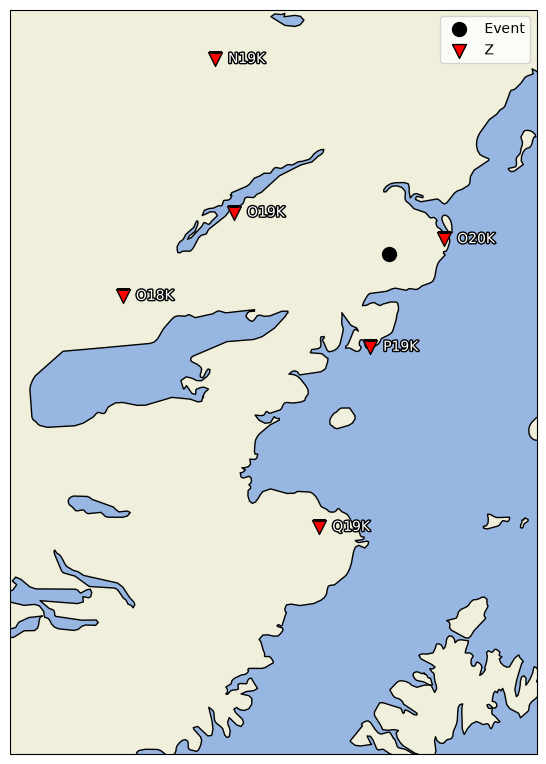

In [ ]:
client = Client('https://service.earthscope.org')

#choose which real network to use for simulation of synthetic data based on given source functions 
#you could also set up fake seismometers based on random coordinates 
inv = client.get_stations(
    network='TA',
    channel='BHZ',
    level='channel',
    latitude=LS_LAT,
    longitude=LS_LON,
    maxradius=1.2 
)
FAKE_STATION_DICT = dict(
)

#avoid duplicate stations
seen=set()
new_networks=[]
for net in inv:
    new_stations=[]
    for sta in net:
        new_channels=[]
        for cha in sta:
            key=(net.code, sta.code, cha.location_code, cha.code)
            if key not in seen:
                seen.add(key)
                new_channels.append(cha)
        if new_channels:
            sta_copy = sta.copy()
            sta_copy.channels = new_channels
            new_stations.append(sta_copy)

    if new_stations:
        net_copy = net.copy()
        net_copy.stations = new_stations
        new_networks.append(net_copy)
inv=Inventory(networks=new_networks, source=inv.source)


data_syn = make_lsdata_syn(
    inv=inv,
    fake_station_dict=FAKE_STATION_DICT,
    source_lat=LS_LAT,
    source_lon=LS_LON,
    data_length_seconds=FAKE_DATA_LENGTH,
)

#plot station and source location 
data_syn.plot_stations(label_stations=True);

In [ ]:
#retrieve green's functions (both force and moment) for each station from syngine
both = LSForce(
    data=data_syn, data_sampling_rate=1, main_folder=main_folder
)

both.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='both', 
    skip_datafilter=True
)

st_combined=both.data.st_proc.copy()

Getting Green's functions...
Found N19K (1/6)
Found O18K (2/6)
Found O19K (3/6)
Found O20K (4/6)
Found P19K (5/6)
Found Q19K (6/6)
Found N19K (1/6)
Found O18K (2/6)
Downloaded O19K (3/6)
Downloaded O20K (4/6)
Downloaded P19K (5/6)
Downloaded Q19K (6/6)


### Create synthetic source-time function

In [ ]:
t = np.arange(FAKE_DATA_LENGTH)
mu = 156
sigma = 10

# ricker wavelet
def ricker(t, mu, sigma):
    x = (t - mu) / sigma
    return (1 - x**2) * np.exp(-0.5 * x**2)

peak_force = 4.5e9
azimuth = 45  

fake_force_z = peak_force * ricker(t, mu, sigma)
fake_force_n = peak_force * 0.6 * np.cos(np.radians(azimuth)) * ricker(t, mu, sigma)
fake_force_e = peak_force * 0.6 * np.sin(np.radians(azimuth)) * ricker(t, mu, sigma)

#keep all moment components zero, simulate a force-only source
components = ['fake_mrr', 'fake_mtt', 'fake_mpp', 'fake_mrt', 'fake_mrp', 'fake_mtp']
globals().update({name: np.zeros(FAKE_DATA_LENGTH) for name in components})

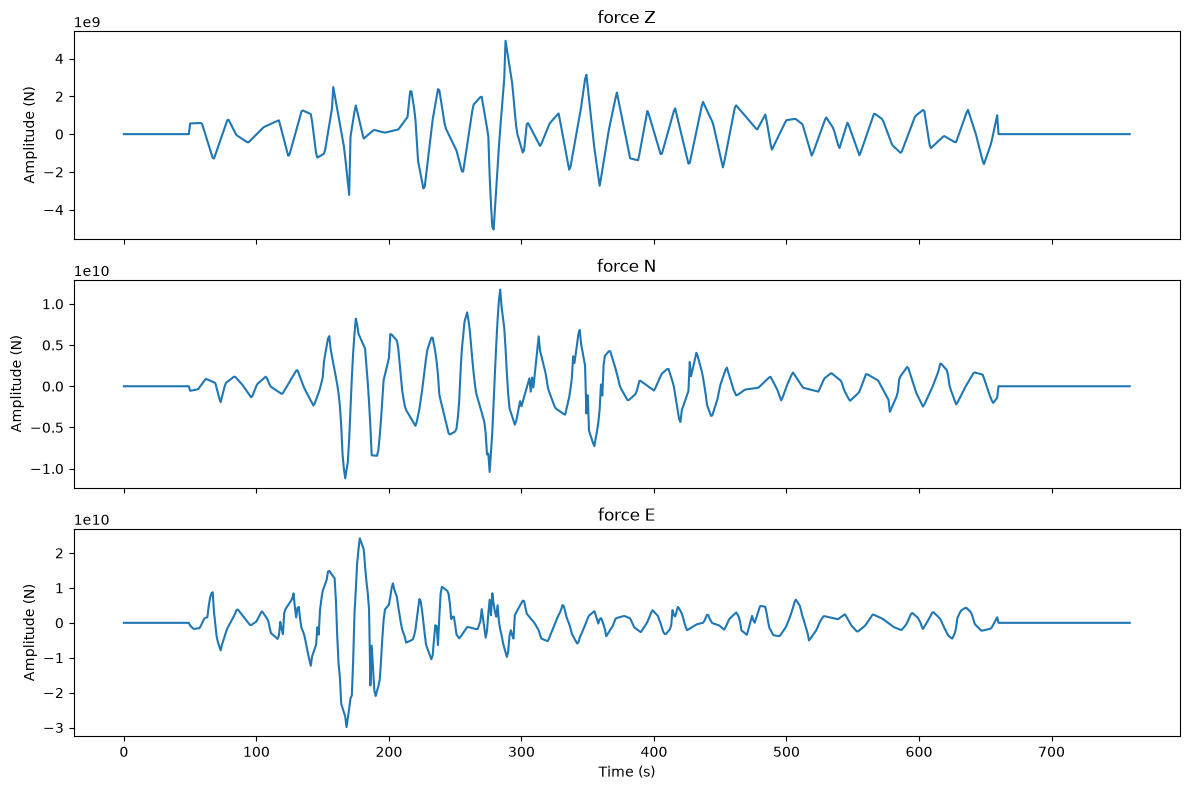

In [ ]:
#visualize source-time function before forward model
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
N_steps=FAKE_DATA_LENGTH
t=np.arange(N_steps)
labels = ['force Z', 'force N', 'force E']
data = [fake_force_z, fake_force_n, fake_force_e]
for ax, lab, d in zip(axs.flat, labels, data):
    ax.plot(t, d)
    ax.set_title(lab)
    ax.xaxis.set_label_text('Time (s)')
    ax.yaxis.set_label_text('Amplitude (N)')
    ax.label_outer()
plt.tight_layout()
plt.show()

### Synthetic Data

In [ ]:
#run synthetic source through a joint forward model
st_combined = both.forward_both(
    fake_force_z, fake_force_n, fake_force_e,
    fake_mrr, fake_mtt, fake_mpp, fake_mrt, fake_mrp, fake_mtp
)


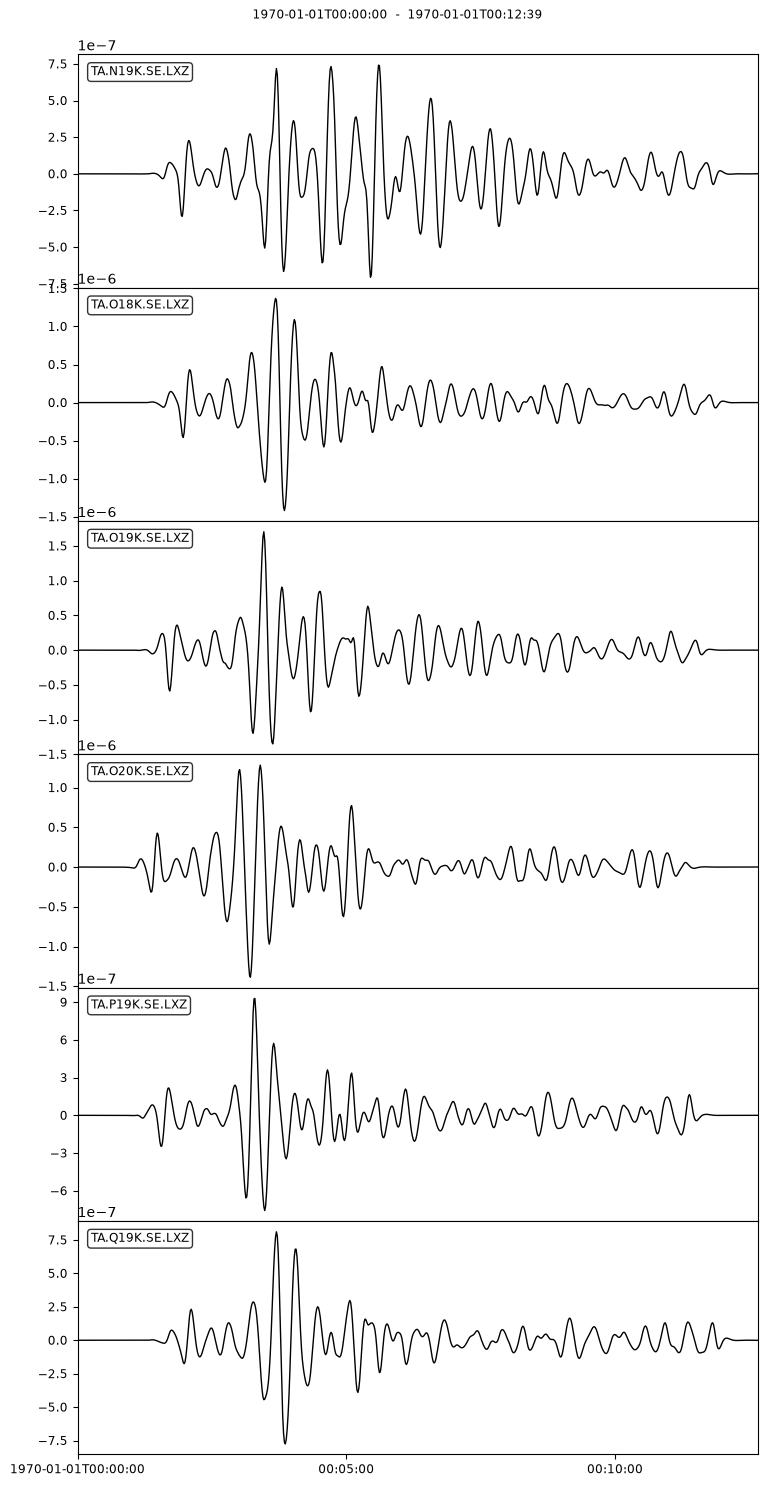

In [ ]:
#visualize synthetic data 
st_combined.plot(equal_scale=False, period_range=PERIOD_RANGE);

### Bayesian Inversions

In [ ]:
#force-only inversion 

st_combined_orig = st_combined.copy()
st_noisy = st_combined_orig.copy()

#add noise to simulate realistic data
rng = np.random.default_rng(seed=42)
noise_level=0.1
for tr in st_noisy:
    peak = np.abs(tr.data).max()
    tr.data = tr.data + rng.normal(0, noise_level * peak, size=tr.data.size)

test_data = LSData(
    st_noisy, source_lat=LS_LAT, source_lon=LS_LON,
    remove_response=False, skip_zne_rotation=True,
)
test_f = LSForce(data=data_syn, data_sampling_rate=1, main_folder=main_folder)

st_noise = test_f.data.st_proc.copy()
st_noise.resample(test_f.data_sampling_rate, window='hann')

#sample noise for a specified time window
noise_window = 100
start= UTCDateTime('1970-01-01T00:00:00')
noise_variances=noise_variance(st_noise, noise_window, 
    event_starttime=start, 
    event_endtime= start+ noise_window)

test_f.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='force',
    skip_datafilter=True
)

#parameters for model 
dt=1
corr_length=5
nugget=1e-6
force_mag=5e10
theta=299
uncertainty=[0.2, 0.2, 0.2]
n = test_f.G.shape[1]
m_prior = np.zeros(n)
m_force, Cm_post_f, Cd_f, misfit_f, misfit_norm_f, model_norm_f, term1_f, bic_f, evidence_f=force_bayesian(test_f, theta, force_mag, uncertainty,dt, nugget, corr_length, m_prior, noise_variances)

#plot results for comparison 
given_forces=[fake_force_z, fake_force_n, fake_force_e]
component_labels=['Z', 'N', 'E']
fig, F_z, F_e, F_n = force_bayesian_plot(m_force, dt, Cm_post_f, given_forces, component_labels, test='yes');

#plot data fit 
stations = sorted(set((tr.stats.network, tr.stats.station) for tr in st_noisy))
components = ['Z', 'R', 'T']
st_obs_filt = test_f.data.st_proc.copy()
_, _, vr_records_force = single_bayesian_forward(test_f, m_force, stations, components, st_obs_filt, FAKE_DATA_LENGTH);

Getting Green's functions...
Found ILULI (1/3)
Found KULLO (2/3)
Found SUMG (3/3)
Log Evidence: 43466.820583241126


In [ ]:
#same as above, moment only inversion

st_combined_orig = st_combined.copy()
st_noisy = st_combined_orig.copy()
rng = np.random.default_rng(seed=42)
noise_level=0.1
for tr in st_noisy:
    peak = np.abs(tr.data).max()
    tr.data = tr.data + rng.normal(0, noise_level * peak, size=tr.data.size)

noise_window = 100
start= UTCDateTime('1970-01-01T00:00:00')
noise_variances=noise_variance(st_noisy, noise_window, 
    event_starttime=start, 
    event_endtime= start+ noise_window)


test_data = LSData(
    st_noisy, source_lat=LS_LAT, source_lon=LS_LON,
    remove_response=False, skip_zne_rotation=True,
)

test_m = LSForce(data=test_data, data_sampling_rate=1, main_folder=main_folder)
st_noise = test_m.data.st_proc.copy()
st_noise.resample(test_m.data_sampling_rate, window='hann')

test_m.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='moment',
    skip_datafilter=True
)


n = test_m.G.shape[1]
m_prior = np.zeros(n)
corr_length=5
uncertainty=.1
mw=4.8
dt=1
nugget=1e-6
m_moment, Cm_post_moment, Cd_m, misfit_m, _, _,  bic_moment, evidence_m= moment_bayesian(test_m, mw, uncertainty, dt, nugget, corr_length, m_prior, noise_variances);

mt_labels = ['Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp']
given_moment=[fake_mrr, fake_mtt, fake_mpp, fake_mrt, fake_mrp, fake_mtp]
moment_bayesian_plot(m_moment, dt, Cm_post_moment, given_moment, mt_labels);

stations = sorted(set((tr.stats.network, tr.stats.station) for tr in st_noisy))
components = ['Z', 'R', 'T']
st_obs_filt = test_m.data.st_proc.copy()
_, _, vr_records_moment = single_bayesian_forward(test_m, m_moment, stations, components, st_obs_filt, FAKE_DATA_LENGTH);

Getting Green's functions...
Downloaded N19K (1/6)
Downloaded O18K (2/6)
Downloaded O19K (3/6)
Downloaded O20K (4/6)
Downloaded P19K (5/6)
Downloaded Q19K (6/6)
Log Evidence: 63007.75499137881


In [ ]:
#joint inversion

st_combined_orig = st_combined.copy()
st_noisy = st_combined_orig.copy()
rng = np.random.default_rng(seed=42)
noise_level=0.1
for tr in st_noisy:
    peak = np.abs(tr.data).max()
    tr.data = tr.data + rng.normal(0, noise_level * peak, size=tr.data.size)

test_data = LSData(
    st_noisy, source_lat=LS_LAT, source_lon=LS_LON,
    remove_response=False, skip_zne_rotation=True,
)

test = LSForce(data=test_data, data_sampling_rate=1, main_folder=main_folder)
st_noise = test.data.st_proc.copy()
st_noise.resample(test.data_sampling_rate, window='hann')

noise_window = 100
start= UTCDateTime('1970-01-01T00:00:00')
noise_variances=noise_variance(st_noise, noise_window, 
    event_starttime=start, 
    event_endtime= start+ noise_window)


test.setup(
    period_range=PERIOD_RANGE,
    syngine_model='iasp91_2s',
    source_type='both',
    skip_datafilter=True
)
dt=1
nugget=1e-8
force_mag=5e10
theta=299
uncertainty_f=[.1, .1, .1]
uncertainty_m=0.1
mw=2.8
corr_length_f=10
corr_length_m=200
n = test.G.shape[1]
m_prior = np.zeros(n)
m_both, Cm_post_both, _, _, _, bic_both, evidence_b=joint_bayesian(test, theta, force_mag, mw, uncertainty_f, uncertainty_m, dt, nugget, corr_length_f, corr_length_m, m_prior, noise_variances);


component_labels = ['Z', 'N', 'E', 'Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp']
given=[fake_force_z, fake_force_n, fake_force_e, fake_mrr, fake_mtt, fake_mpp, fake_mrt, fake_mrp, fake_mtp]
joint_plots(component_labels, m_both, m_force, m_moment, Cm_post_both, dt, given);

components = ['Z', 'R', 'T']
st_obs_filt = test.data.st_proc.copy()
stations = sorted(set((tr.stats.network, tr.stats.station) for tr in st_obs_filt))
single_bayesian_forward(test, m_both, stations, components, st_obs_filt, FAKE_DATA_LENGTH);

Getting Green's functions...
Found N19K (1/6)
Found O18K (2/6)
Found O19K (3/6)
Found O20K (4/6)
Found P19K (5/6)
Found Q19K (6/6)
Found N19K (1/6)
Found O18K (2/6)
Found O19K (3/6)
Found O20K (4/6)
Found P19K (5/6)
Found Q19K (6/6)
Log Evidence: 67441.90178630079


In [ ]:
#compare evidence values across inversion scheme 

evidence_table = pd.DataFrame({
    'Scheme': ['Force', 'Moment', 'Joint'],
    'Evidence': [evidence_f, evidence_m, evidence_b],
})

print(evidence_table)

   Scheme      Evidence
0   Force  43466.820583
1  Moment  42526.540976
2   Joint  42525.478723
